# Distribución Muestral y Teorema del Límite Central

## Objetivo

Demostrar cómo las medias muestrales se distribuyen de manera aproximadamente normal según el Teorema del Límite Central (TLC), incluso si la variable original no sigue una distribución normal.

Se utilizará el dataset de hábitos saludables de 150 estudiantes universitarios para generar múltiples muestras de distintos tamaños y analizar la distribución de la media.

## Variables de interés

- Horas de sueño
- Horas de ejercicio
- Nivel de estrés

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/habitos_saludables_estudiantes.csv")
data

Mounted at /content/drive


,edad,genero,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
0,18,Masculino,6.9,2.0,0,6,5.98
1,25,Femenino,5.6,1.2,2,10,6.31
2,28,Femenino,7.6,0.7,1,8,4.88
3,20,Masculino,6.3,1.2,3,3,5.20
4,28,Femenino,6.1,3.1,4,10,5.49
...,...,...,...,...,...,...,...
145,27,Masculino,5.7,3.0,3,10,5.59
146,27,Masculino,6.9,6.5,3,2,6.40
147,29,Masculino,7.7,3.6,1,3,6.12
148,26,Masculino,5.0,3.3,2,1,5.60


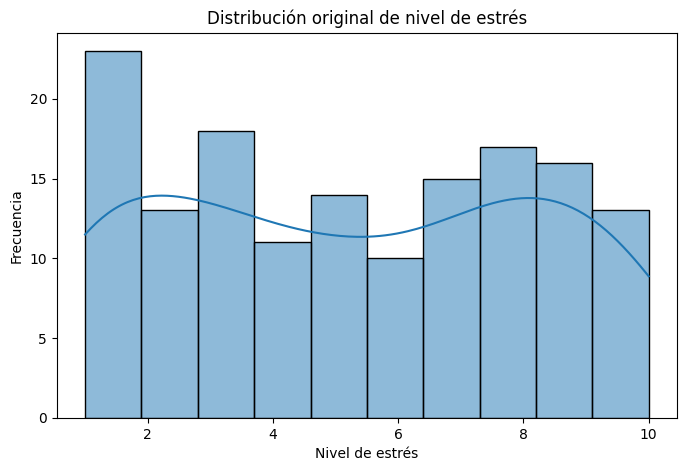

In [3]:
#Visualización de la distribución original
plt.figure(figsize=(8,5))
sns.histplot(data["estres"], bins=10, kde=True)
plt.title("Distribución original de nivel de estrés")
plt.xlabel("Nivel de estrés")
plt.ylabel("Frecuencia")
plt.show()

In [4]:
#Función para generar distribuciones muestrales
def generar_medias_muestrales(variable, n_muestras=1000, tam_muestra=10):
    medias = []
    for _ in range(n_muestras):
        muestra = variable.sample(tam_muestra, replace=True)
        medias.append(muestra.mean())
    return medias

Se generan distribuciones muestrales para tamaños de muestra: 5, 10, 30, 50.  
Observaremos cómo a medida que aumenta el tamaño de muestra, la distribución de la media se vuelve más cercana a una normal.

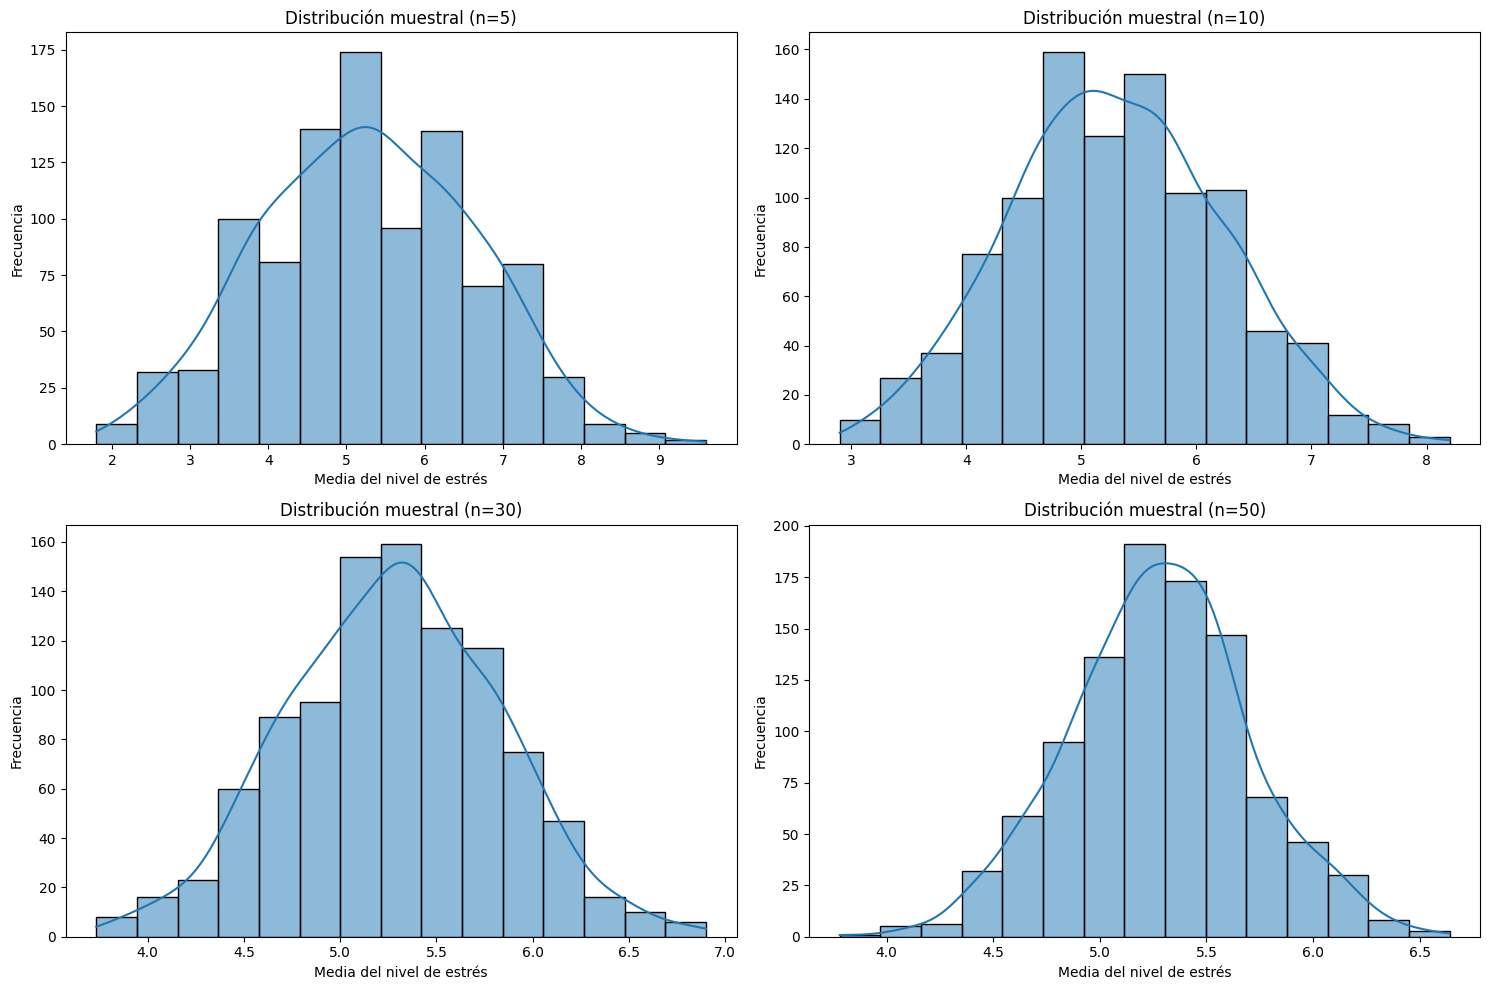

In [5]:
n_muestras = 1000
tam_muestras = [5, 10, 30, 50]
variable = data["estres"]

plt.figure(figsize=(15,10))

for i, n in enumerate(tam_muestras,1):
    medias = generar_medias_muestrales(variable, n_muestras, n)

    plt.subplot(2,2,i)
    sns.histplot(medias, bins=15, kde=True)
    plt.title(f"Distribución muestral (n={n})")
    plt.xlabel("Media del nivel de estrés")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

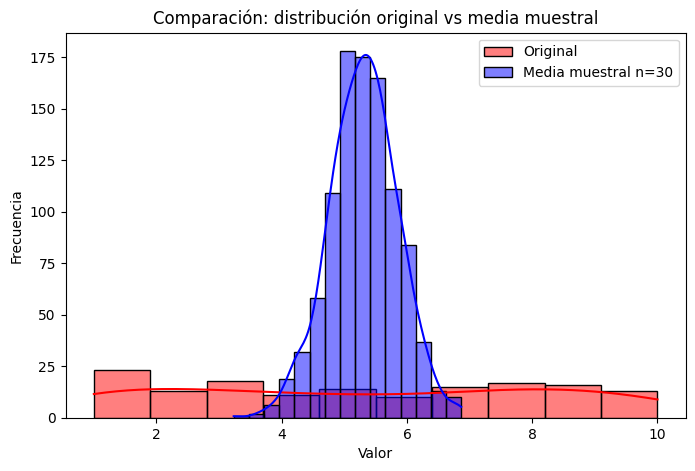

In [6]:
#Comparación con la distribución original
plt.figure(figsize=(8,5))
sns.histplot(variable, bins=10, kde=True, color='red', label='Original')
sns.histplot(generar_medias_muestrales(variable, n_muestras, 30), bins=15, kde=True, color='blue', label='Media muestral n=30')
plt.title("Comparación: distribución original vs media muestral")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

##Esto demuestra cómo la media muestral tiende a normalizarse aunque la variable original no sea normal.

In [7]:
#Análisis de dispersión según tamaño de muestra
for n in tam_muestras:
    medias = generar_medias_muestrales(variable, n_muestras, n)
    print(f"Tamaño muestra={n} → Desviación estándar media muestral: {np.std(medias):.3f}")

Tamaño muestra=5 → Desviación estándar media muestral: 1.371
Tamaño muestra=10 → Desviación estándar media muestral: 0.961
Tamaño muestra=30 → Desviación estándar media muestral: 0.552
Tamaño muestra=50 → Desviación estándar media muestral: 0.438


Observación: A medida que aumenta n, la dispersión de la media disminuye, lo cual es consistente con el TLC.

## Conclusiones

1. La distribución original del nivel de estrés es discreta y no normal.
2. Al generar distribuciones muestrales de la media con distintos tamaños de muestra, se observa que:
   - Para muestras pequeñas, la media presenta cierta dispersión y forma irregular.
   - Para muestras más grandes (≥30), la distribución de la media se aproxima a una curva normal.
3. La desviación estándar de la media disminuye al aumentar el tamaño de muestra, mostrando mayor precisión en la estimación de la media poblacional.
4. Esto confirma empíricamente el Teorema del Límite Central y proporciona la base para aplicar inferencia estadística en las siguientes lecciones (intervalos de confianza y pruebas de hipótesis).